In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [2]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


C:\Users\Matth\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:


linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Kr"])

imagePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\TestArcCalib.HK.fits"
spec2D = fits.open(imagePath)[0].data
Spec2D.flipX(spec2D)

spec = Spec1D.convert2Dto1D(spec2D, 250, 300)
continuum = Spec1D.continuum(spec)
contSub = spec - continuum(np.arange(0, len(spec)))

Interactive Linear fit! Once this is cell is finish searching the parameter space (takes around 10 minutes on my machine with these resolution parameters), click the heatmap to see how the model changes with those parameters. The red x is located at the best solution that the machine found.

11702.341137123745 0.13545150501672243


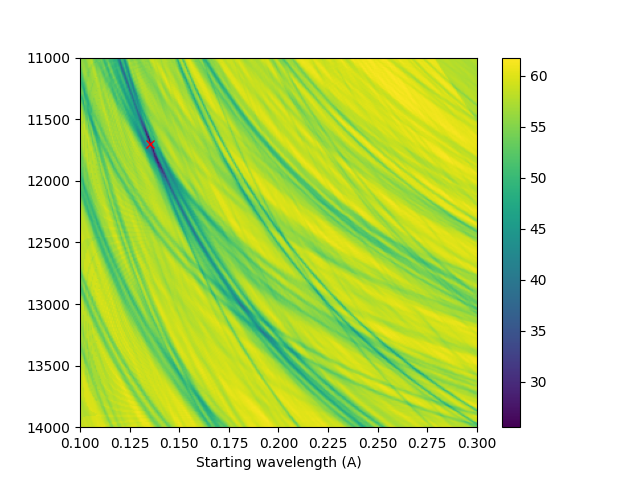

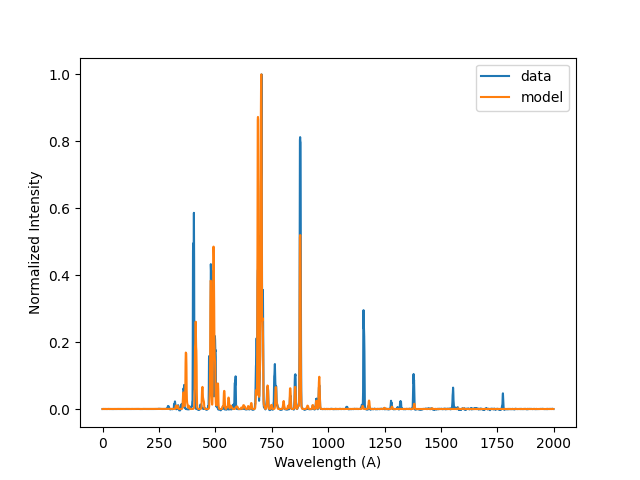

In [5]:
w, a = Spec1D.calcLinearFit(contSub, lines, 11000, 14000, 0.1, 0.3, resW=300, resS=300)
print(w, a)

In [6]:
w=11684.684684684684 
a=0.13503503503503503

In [7]:
wavs = np.linspace(Spec1D.pixelToWav(0, w, a), Spec1D.pixelToWav(len(contSub)-1, w, a), len(contSub))
norm = contSub/np.max(contSub)
params = []
model = np.zeros_like(norm)

Interactive line analysis! To start editing the model lines, press the 'e' key on your keyboard to enable editing. Make sure you press the 'e' key a second time to disable editing if you want to resize or move around the spectrum!

Once you are in edit mode and can identify a single line that you would like to model, left click on the top of the line to fit it. If you misclick or the fit is bad, right click anywhere on the graph to remove it.

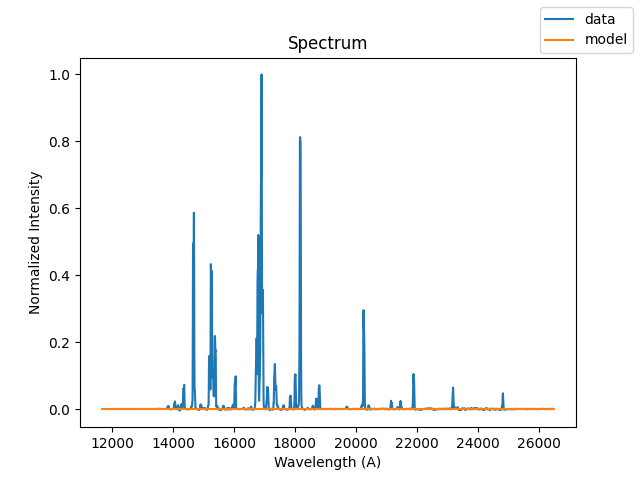

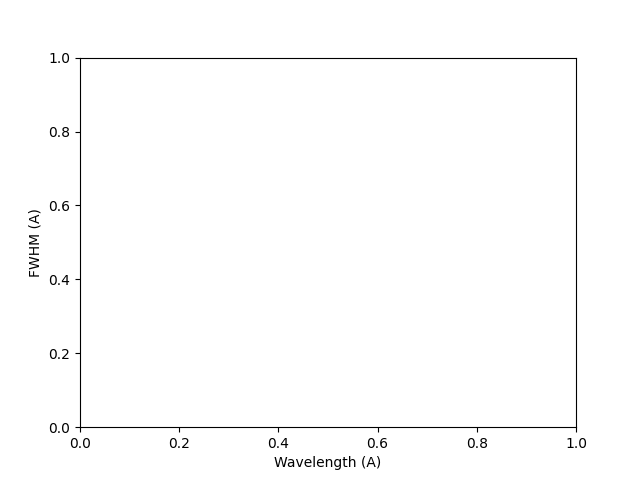

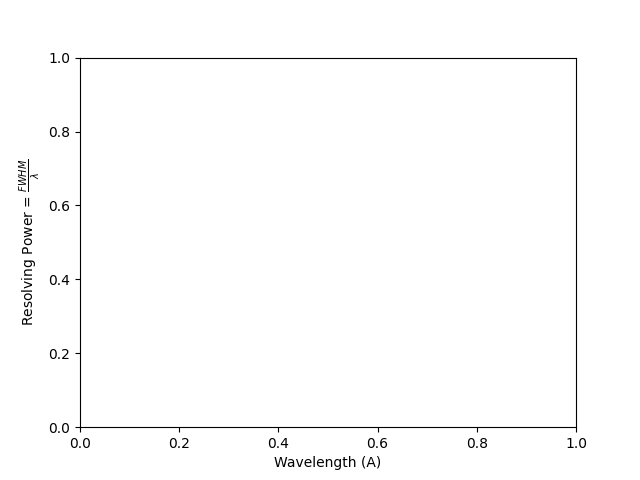

In [8]:
fig, ax = plt.subplots()
ax.set_title("Spectrum")
ax.set_xlabel("Wavelength (A)")
ax.set_ylabel("Normalized Intensity")
ax.plot(wavs,norm, label="data")
line, = ax.plot(wavs, model, label="model")
fig.legend()

FWFig, FWAx = plt.subplots()
FWAx.set_xlabel("Wavelength (A)")
FWAx.set_ylabel("FWHM (A)")
RFig, RAx = plt.subplots()
RAx.set_xlabel("Wavelength (A)")
RAx.set_ylabel("Resolving Power = $\\frac{FWHM}{\\lambda}$")

def updateGraphs():
    line.set_ydata(model)
    fig.canvas.draw()
    fig.canvas.flush_events()

    tmp = np.array(params)
    FWHMs = Spec1D.LorentzWidthToFWHM(tmp[:,2])
    FWAx.clear()
    FWAx.plot(tmp[:,0], FWHMs, "o")
    FWAx.set_xlabel("Wavelength (A)")
    FWAx.set_ylabel("FWHM (A)")
    FWFig.canvas.draw()
    FWFig.canvas.flush_events()

    RAx.clear()
    RAx.plot(tmp[:,0], tmp[:,0]/FWHMs, "o")
    RAx.set_xlabel("Wavelength (A)")
    RAx.set_ylabel("Resolving Power = $\\frac{FWHM}{\\lambda}$")
    RFig.canvas.draw()
    RFig.canvas.flush_events()

if len(params)>0:
    updateGraphs()

def onclick(event):
    global model
    if edit:
        if event.button == 1: #button 1 is left mouse button
            l = event.xdata
            index=Spec1D.wavToPixel(l, w, a)
            intensities=norm[index-9:index+9]
            wavSec = wavs[index-9:index+9]
            var, cov = curve_fit(Spec1D.LorentzLine, wavSec, intensities, (l, event.ydata, 20, 0, 2),bounds=([l-50,0,0,0,0],[l+50, 1,200,1e-5,np.inf]), sigma=np.sqrt(np.abs(intensities)), absolute_sigma=True)
            params.append(var)
            #params is center wavelength, amplitude, width, offset, and power
            model += Spec1D.LorentzLine(wavs, params[-1][0], params[-1][1], params[-1][2], 0, params[-1][4])

            #refresh the canvas
        if event.button == 3: #right mouse button
            model -= Spec1D.LorentzLine(wavs, params[-1][0], params[-1][1], params[-1][2], 0, params[-1][4])
            params.pop()
        
        updateGraphs()

edit = False
def onkey(event):
    global edit
    print(event.key)
    if event.key == "e":
        if edit:
            edit = False
        else:
            edit = True

cid = fig.canvas.mpl_connect('button_press_event', onclick)
cid = fig.canvas.mpl_connect('key_press_event', onkey)